# 4 · Multi-ancestry fine-mapping

In a multi-ancestry study the individuals are **disjoint across ancestries** — each
ancestry has its own genotype matrix and its own samples — but we believe they share
(largely) the same causal variants, possibly with ancestry-specific effect sizes.
Fine-mapping jointly exploits the *different LD patterns* across ancestries to narrow the
credible set far more than any single ancestry could.

This is the `BlockDesign` axis: genotypes are stacked as `(K, N, M)` and
`eta[k] = X[k] @ B[:, k]` has shape `(K, N)`. The `sushie` prior places a dense `K x K`
covariance on the per-ancestry effect vector, letting effects correlate across ancestries
while still allowing them to differ.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
rng = np.random.default_rng(0)  # NumPy RNG for the simulations (deterministic)

## Simulate K ancestries with distinct LD

Each ancestry gets its own genotype matrix (here with its own AR(1) LD strength, so the
correlation structure genuinely differs across ancestries) and its own samples. One
shared causal variant `j` has ancestry-specific effect sizes.

In [2]:
K, N, M, j = 3, 350, 150, 70
ld_strengths = [0.9, 0.7, 0.5]              # different LD decay per ancestry
effects = np.array([1.2, 0.9, 1.4])         # ancestry-specific effect of variant j

idx = np.arange(M)
X = np.empty((K, N, M))
y = np.empty((K, N))
for k in range(K):
    Sigma_ld = ld_strengths[k] ** np.abs(idx[:, None] - idx[None, :])
    chol = np.linalg.cholesky(Sigma_ld + 1e-6 * np.eye(M))
    Xk = rng.standard_normal((N, M)) @ chol.T
    Xk = (Xk - Xk.mean(0)) / Xk.std(0)      # standardise within ancestry
    X[k] = Xk
    y[k] = Xk[:, j] * effects[k] + rng.standard_normal(N)
print("X:", X.shape, " y:", y.shape, " causal:", j)

X: (3, 350, 150)  y: (3, 350)  causal: 70


## Fine-map with `BlockDesign` + `sushie`

The Gaussian likelihood is applied to the stacked `(K, N)` responses; the `BlockDesign`
routes each ancestry's effects through its own genotypes.

`L` is an *upper bound* on the number of signals — we set `L=3` even though there is one
true causal. Unused single effects have their prior variance shrunk toward zero by
empirical Bayes and spread their (tiny) inclusion mass diffusely, so they don't survive
the credible-set purity filter: we get back exactly one credible set.

In [3]:
from lasusie import finemap, Model, likelihoods, priors
from lasusie.design import BlockDesign

model = Model(
    design=BlockDesign(X=jnp.asarray(X)),
    likelihood=likelihoods.gaussian(jnp.asarray(y), sigma2=1.0),
    prior=priors.sushie(jnp.eye(K)),
    log_pi=jnp.full(M, -jnp.log(M)),
)
result = finemap(model, L=3, coverage=0.95, purity=0.5)
print(f"top variant = {int(np.argmax(result.pip))}  (true = {j}),  PIP = {result.pip[j]:.3f}")

top variant = 70  (true = 70),  PIP = 1.000


## PIPs and credible sets

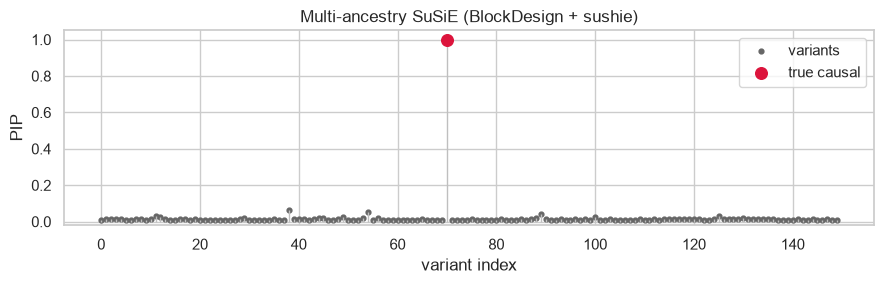

,effect,size,coverage,purity,variants
0,0,1,1.0,1.0,[70]


In [4]:
def credible_set_table(result):
    rows = []
    for cs in result.credible_sets:
        if not cs.kept:
            continue
        rows.append({"effect": cs.effect, "size": len(cs.variants),
                     "coverage": round(float(cs.coverage), 3),
                     "purity": round(float(cs.purity), 3),
                     "variants": list(np.asarray(cs.variants)[:8])})
    return pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 3))
m = np.arange(M)
ax.vlines(m, 0, result.pip, color="0.75", lw=1)
ax.scatter(m, result.pip, s=12, color="0.4", label="variants")
ax.scatter(j, result.pip[j], s=70, color="crimson", zorder=3, label="true causal")
ax.set(xlabel="variant index", ylabel="PIP", ylim=(-0.02, 1.05),
       title="Multi-ancestry SuSiE (BlockDesign + sushie)")
ax.legend(); plt.tight_layout(); plt.show()

credible_set_table(result)

## Recovered ancestry-specific effect sizes

Because the prior is a dense `K x K` covariance, each single effect stores a *vector* of
per-ancestry effect sizes in `result.posterior.mean` (shape `(L, M, K)`). Reading it at
the causal variant recovers the ancestry-specific effects we simulated.

In [5]:
# which single effect (l) captured the causal variant?
alpha = np.asarray(result.alpha)          # (L, M)
l_star = int(np.argmax(alpha[:, j]))
est = np.asarray(result.posterior.mean)[l_star, j]    # (K,) per-ancestry effect estimate

comparison = pd.DataFrame({
    "ancestry": [f"anc{k}" for k in range(K)],
    "true_effect": effects,
    "estimated_effect": est.round(3),
})
comparison

,ancestry,true_effect,estimated_effect
0,anc0,1.2,1.252
1,anc1,0.9,0.978
2,anc2,1.4,1.389


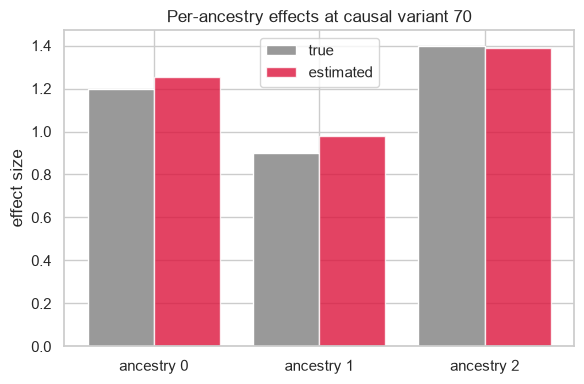

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
xpos = np.arange(K)
ax.bar(xpos - 0.2, effects, width=0.4, label="true", color="0.6")
ax.bar(xpos + 0.2, est, width=0.4, label="estimated", color="crimson", alpha=0.8)
ax.set_xticks(xpos); ax.set_xticklabels([f"ancestry {k}" for k in range(K)])
ax.set_ylabel("effect size"); ax.set_title(f"Per-ancestry effects at causal variant {j}")
ax.legend(); plt.tight_layout(); plt.show()

Jointly modelling the three ancestries — each with a *different* LD pattern — pins the
signal to the true causal variant and recovers its ancestry-specific effect sizes, all
from a single `finemap` call with the `BlockDesign` axis.